## Modelo S com data augmentation

In [9]:
# dependencies
from keras.utils import image_dataset_from_directory
from tensorflow import keras
from keras import layers
import matplotlib.pyplot as plt
from keras import layers, regularizers
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.preprocessing import image
import numpy as np

Load das imagens a ser utilizadas no treino e teste:

In [10]:
train_dir = 'train'
validation_dir = 'validation'
test_dir = 'test'

IMG_SIZE = 32

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32) 
validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)
test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


Para este modelo, começámos com um data augmentation com probabilidade de rotação de 0.1 e probabilidade de zoom de 0.2. No entanto, após várias tentativas, decidimos alterar esses valores para 0.2 e 0.3, respetivamente, tendo registado pequenas melhorias na accuracy final.

In [11]:
data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.3),
])

Imagens com data augmentation:

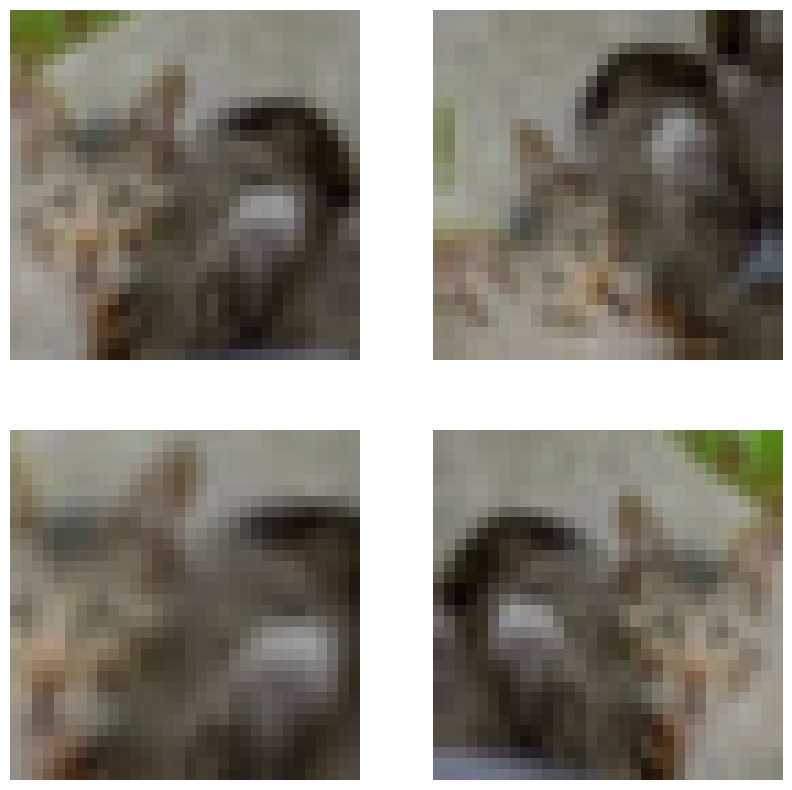

In [12]:
# apresentar 4 primeiras imagens da primeira batch
plt.figure(figsize=(10, 10))
for images, _ in train_dataset.take(1):
  for i in range(4):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(2, 2, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

3 imagens aleatórias do dataset de treino:

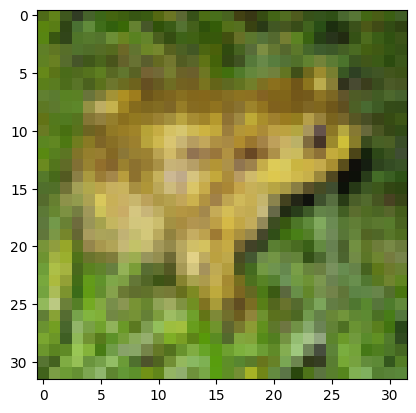

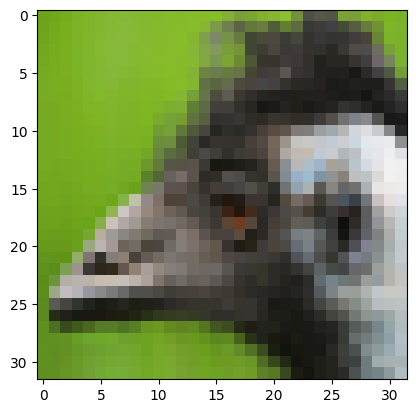

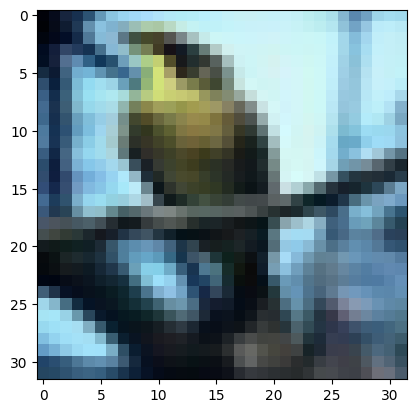

In [13]:
for data_batch, _ in train_dataset.take(1):
  for i in range(3):
    plt.imshow(data_batch[i].numpy().astype("uint8"))
    plt.show()

**Modelo 1**:
Inicialmente começamos com o seguinte modelo: 

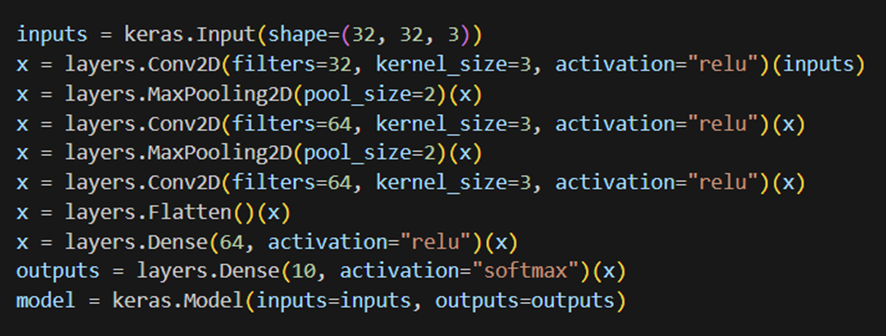

Este modelo, ainda muito primitivo, não usava data augmentation e a accuracy mais alta que registou foi: 0.6372, uma vez que rapidamente se começava a registar overfitting.

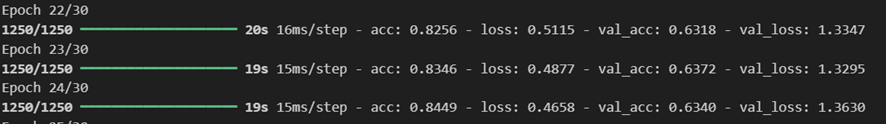
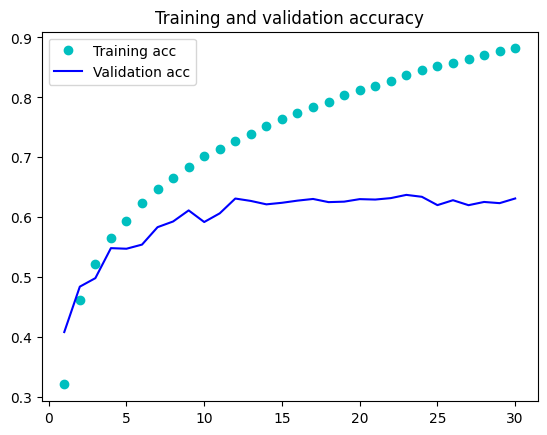

Por análise do gráfico, facilmente concluimos que o modelo obtém muito bons resultados relativamente ao conjunto de treino, mas mostra-se ineficaz para prever novos resultados (conjunto de validação), uma vez que a accuracy de validação para de evoluir muito cedo.
Este problema ocorre quando o modelo se adequa demasiado ao conjunto de treino, não tendo boa capacidade de generalização.

**Modelo 2**:
Decidimos então aplicar data augmentation, com probabilidade de rotação de 0.1 e probabilidade de zoom de 0.2.

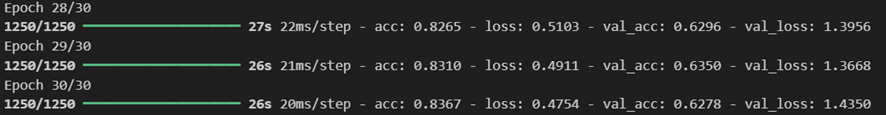
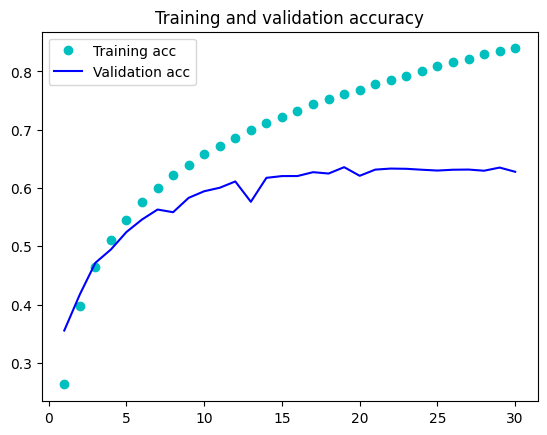

No entanto, é possível perceber que esta medida não foi suficiente para resolver o problema de overfitting, uma vez que a accuracy de validação continua estagnar muito cedo.

**Modelo 3**:
Decidimos aplicar dropout (0.5) que consiste (com 50% de probabilidade) em aleatoriamente "desligar" um número de features de saída da camada a que é aplicada durante o treino e decidimos também alterar o número de filtros, reduzindo bastante o overfitting e aumentando a accuracy.
Podemos perceber que nas últimas épocas a training accuracy ultrapassa a validation accuracy, o que pode ser sinal de overfitting.

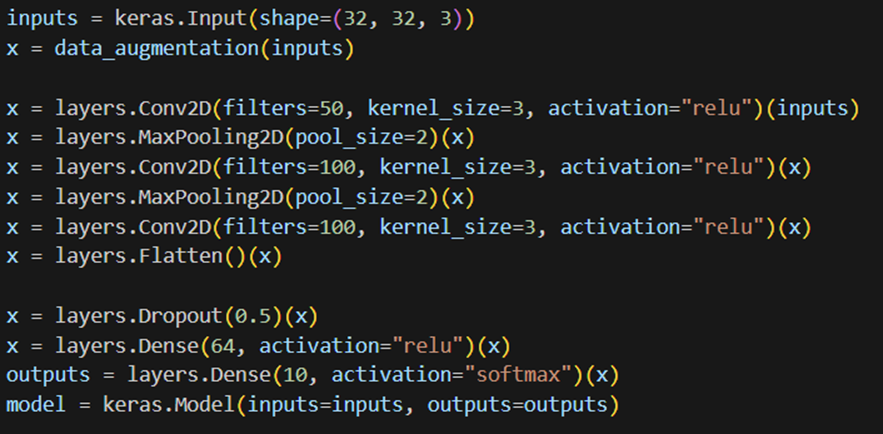
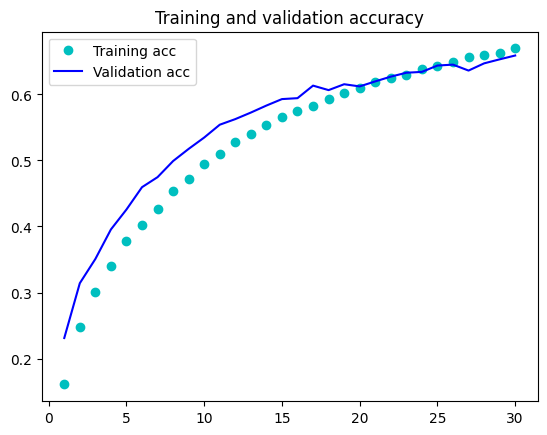
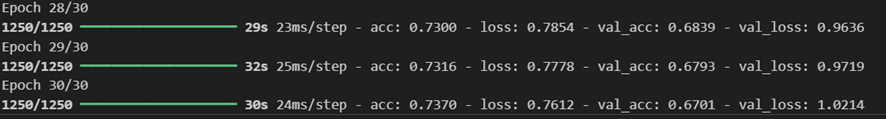

**Modelo 4**:
Tentámos alterar os números de filtros e adicionámos dropouts na tentativa de obter uma melhor accuracy, mas não tivemos sucesso, tendo a accuracy piorado e assim revertemos as alterações.

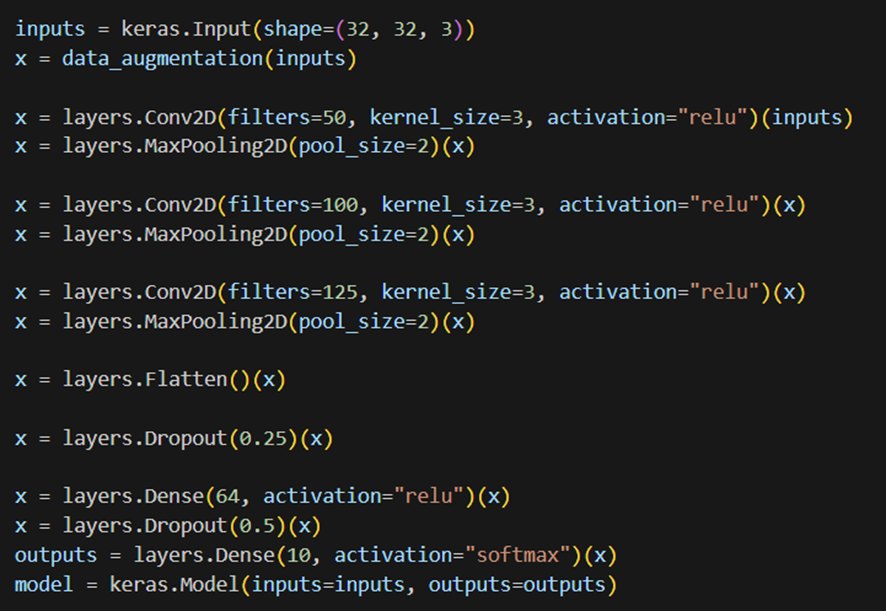
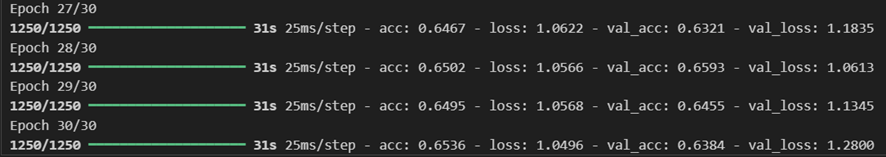

**Modelo 5**:
Adicionámos um dropout e alterámos o número de neurónios na camada densa, obtendo uma accuracy semelhante à que tínhamos obtido no modelo 3, no entanto não ocorrendo overfitting.

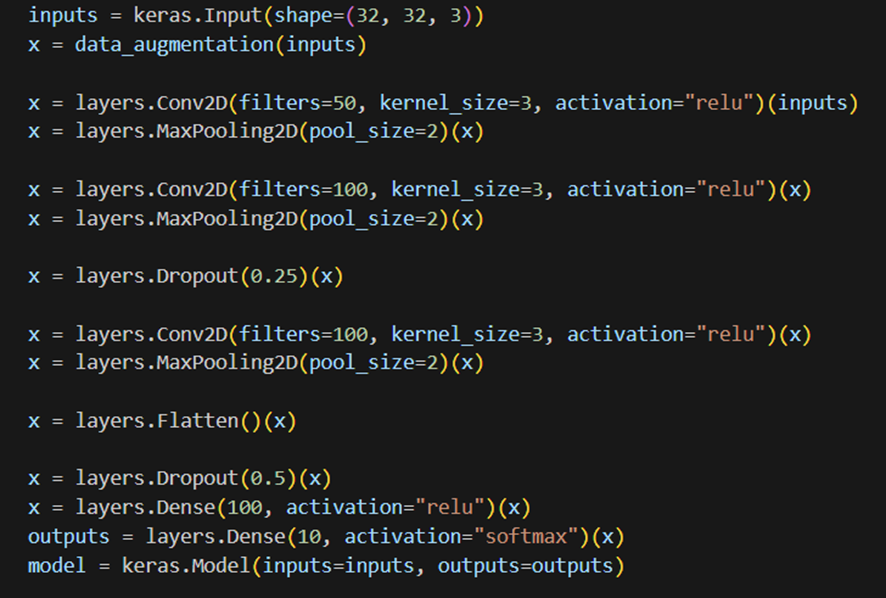
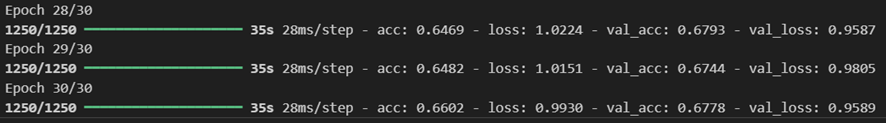
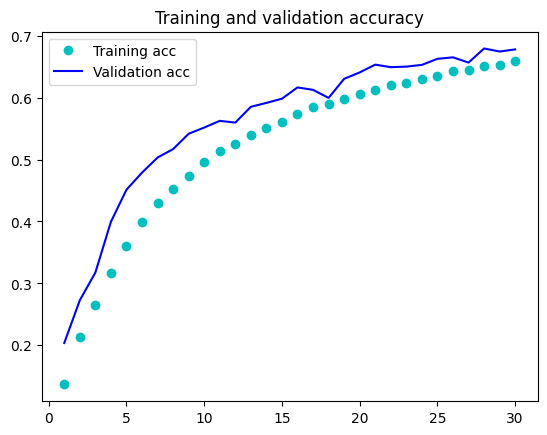

**Modelo 6**:
Implementámos L2 regularization, que consiste em adicionar à função de custo uma penalização proporcional ao quadrado dos pesos da rede, com o objetivo de evitar overfitting.
Além disso, implementámos também early stopping, que consiste em parar o treino da rede quando a accuracy de validação começa a diminuir, evitando assim overfitting.

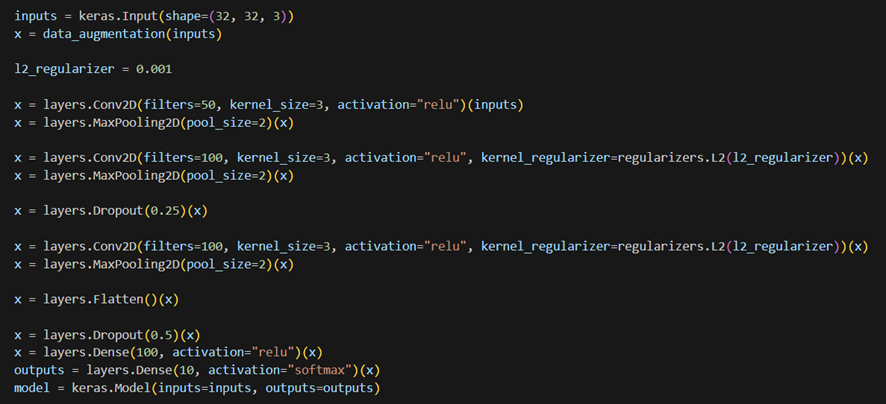
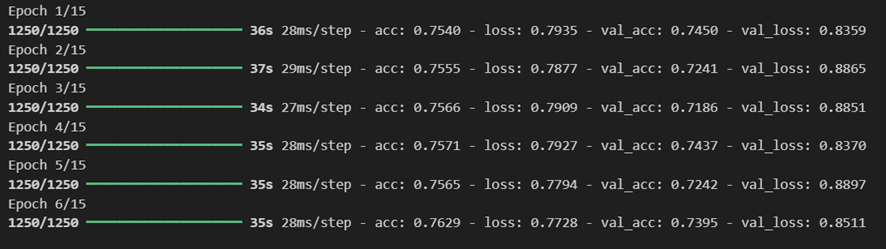
(30 épocas + 15, tendo terminado mais cedo pelo early stopping)

Por fim, alterámos parâmetros da data augmentation, adicionámos mais um dropout e uma camada densa, obtendo o modelo.

In [14]:
inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)

l2_regularizer = 0.001

x = layers.Conv2D(filters=50, kernel_size=3, activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Dropout(0.25)(x)

x = layers.Conv2D(filters=100, kernel_size=3, activation="relu", kernel_regularizer=regularizers.L2(l2_regularizer))(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)

x = layers.Dropout(0.5)(x)
x = layers.Dense(100, activation="relu")(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(25, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 100)      │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,485 (701.11 KB)

 Trainable params: 179,485 (701.11 KB)

 Non-trainable params: 0 (0.00 B)

Compilação do modelo usando o optimizador RMSprop com uma learning rate = 1e-4. Foi testado também com learning rate = 1e-3 e 1e-5, tendo sido com 1e-4 que obtivemos melhores resultados. Implementação de optimizer='adam' no ficheiro modelo_base_adam.ipynb.

In [15]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

Treino do modelo que será guardado em model_s_sem_optuna.keras. Modelo parou de treinar na época 92/200 devido ao early stopping com patience=10, que significa que o treino é interrompido se a accuracy de validação não melhorar durante 10 épocas. ModelCheckpoint guarda o modelo com a melhor accuracy de validação.

In [ ]:
model_filename = 'models/model_s_sem_optuna.keras'

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# para salvar o melhor modelo
checkpoint_callback = ModelCheckpoint(
    model_filename,
    monitor='val_acc', 
    save_best_only=True,
    mode='max',
    save_weights_only=False
)

# Training the model
history = model.fit(train_dataset, epochs=200, validation_data=validation_dataset, callbacks=[early_stopping, checkpoint_callback])


Epoch 1/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 39s 29ms/step - acc: 0.1211 - loss: 5.2435 - val_acc: 0.1982 - val_loss: 2.1818
Epoch 2/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - acc: 0.2121 - loss: 2.1658 - val_acc: 0.2886 - val_loss: 1.9616
Epoch 3/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - acc: 0.2727 - loss: 1.9684 - val_acc: 0.3377 - val_loss: 1.8204
Epoch 4/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - acc: 0.3223 - loss: 1.8461 - val_acc: 0.3845 - val_loss: 1.7238
Epoch 5/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - acc: 0.3642 - loss: 1.7480 - val_acc: 0.4292 - val_loss: 1.6435
Epoch 6/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - acc: 0.3994 - loss: 1.6691 - val_acc: 0.4274 - val_loss: 1.6106
Epoch 7/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - acc: 0.4295 - loss: 1.5887 - val_acc: 0.4864 - val_loss: 1.5043
Epoch 8/200
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - acc: 0.4564 - loss: 1.5253 - val_acc: 0.4999 - val_loss: 1.4305
Epoch 9/200
1250

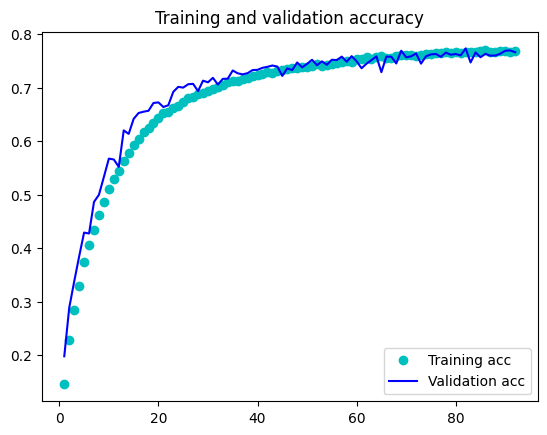

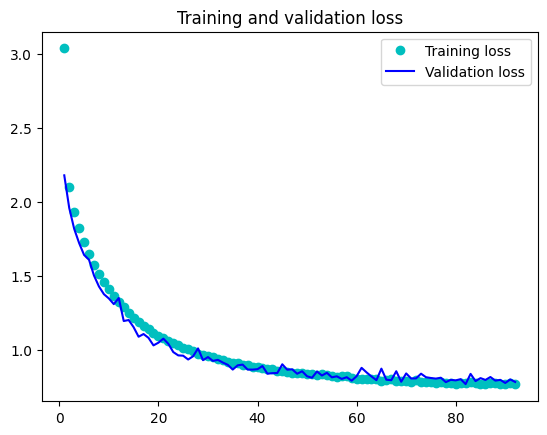

In [17]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'co', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'co', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# validation acc e validation loss é a que realmente importa

Por análise do gráfico e da test accuracy, podemos concluir que o modelo para de ser treinado quando começam a haver indícios de overfitting.
A validation accuracy mantém-se maior que a training accuracy até por volta da época 60. A partir daí ambas assumem valores semelhantes, no entanto, embora a training accuracy seja maior que a de validation, não significa que este modelo esteja já a sofre overfitting. Overfitting dá se quando a diferença destes valores é significativa. 
Com uma test accuracy de 0.78, concluímos que este modelo estará pronto para imagens que não pertencem às de treino.

In [27]:
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f'Test accuracy: {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 136ms/step - acc: 0.7821 - loss: 0.7485
Test accuracy: 0.7799000144004822


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

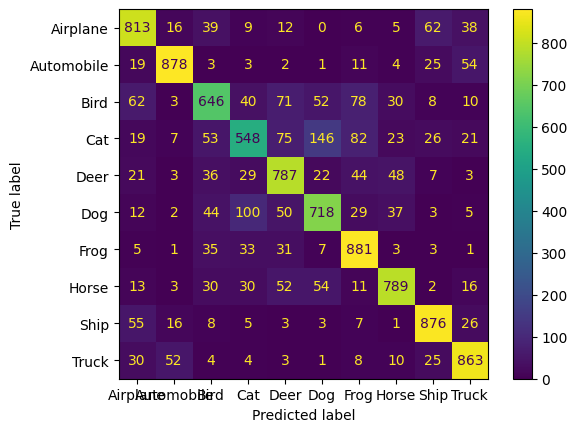

In [36]:
from sklearn import metrics


y_true = []
y_pred = []

# Iterate over the test dataset to get predictions and true labels
for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute the confusion matrix
conf_mat = metrics.confusion_matrix(y_true, y_pred)

# display matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"])
cm_display.plot()
plt.show()


Por análise da matriz de confusão, entende-se que o modelo apresenta resultados maioritariamente satisfatórios, com exceção de algumas classes que apresentam uma taxa de acerto menor. A destacar são as classes bird e cat, que são aquelas em que o modelo apresenta maior dificuldade em classificar corretamente, tendo em 1000 imagens acertado em 646 e 548, respetivamente. Outro ponto a destacar é que a classe pela qual 'cat' é mais confundida é a classe 'dog' e vice-versa, revelando que o modelo tem dificuldade em distinguir entre estas duas classes. As classes com maior taxa de acerto são 'frog' e 'automobile', com 881 e 878 imagens corretamente classificadas, respetivamente.

Exemplo de uma imagem corretamente classificada:

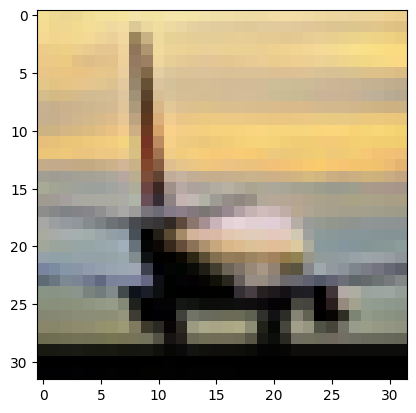

(1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Model predicts:  airplane
Result:  [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [24]:
img = tf.keras.preprocessing.image.load_img('test/000_airplane/aeroplane_s_000002.png', target_size=(32, 32), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = model.predict(img_array)
whatIsIt = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predicted_classes = result.round()
predicted_index = np.where(predicted_classes == 1)[1]

print("Model predicts: ", whatIsIt[predicted_index[0]])
print("Result: ", result.round())